In [27]:
import sys
sys.path.append('/host/d/Github')

import os
import json
import math
from math import erf, sqrt

import numpy as np
import pandas as pd
import nibabel as nb
import matplotlib.pyplot as plt

from tkinter import font

import radiomics
from radiomics import (
    featureextractor,  # This module is used for interaction with pyradiomics
)

from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

import Osteosarcoma.functions_collection as ff
import Osteosarcoma.Build_lists.Build_list as Build_list

In [28]:

def plot_roc_curve(y_true, y_prob, figsize=(6,6), title = "ROC curve", save_true = False, save_path = None):

    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)

    plt.figure(figsize=figsize)
    plt.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {auc:.3f})')
    plt.plot([0,1], [0,1], '--', lw=1)   # random guess line
    plt.xlim([0,1])
    plt.ylim([0,1.05])
    plt.xlabel("False Positive Rate", fontsize = 13)
    plt.ylabel("True Positive Rate" , fontsize = 13)
    plt.title(title , fontsize = 14)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    if not save_true:
        plt.show()
    if save_true and save_path is not None:
        plt.savefig(save_path)

### patient split

In [ ]:
random_state = 60

In [30]:
split_out_path = '/host/e/D/Data/Habitats/Jishuitan/Patient_lists/image_label_info_set12_5fold_prognosis.xlsx'
if os.path.exists(split_out_path):
    print("File exists:", split_out_path)
else:
    # 1) load
    df = pd.read_excel('/host/e/D/Data/Habitats/Jishuitan/Patient_lists/image_label_info_set12.xlsx')

    label_col = "Prognosis_label"
    y = df[label_col].astype(int).values  # 确保是0/1

    # 2) stratified 5-fold
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    df["fold"] = -1
    for fold_id, (_, val_idx) in enumerate(skf.split(df, y)):
        df.loc[val_idx, "fold"] = fold_id

    # 3) quick check: each fold label ratio
    summary = (
        df.groupby("fold")[label_col]
        .agg(["count", "sum", "mean"])
        .rename(columns={"sum": "n_pos", "mean": "pos_ratio"})
    )
    print(summary)

    out_path = "/host/e/D/Data/Habitats/Jishuitan/Patient_lists/image_label_info_set12_5fold_prognosis.xlsx"
    df.to_excel(out_path, index=False)
    print("Saved:", out_path)

File exists: /host/e/D/Data/Habitats/Jishuitan/Patient_lists/image_label_info_set12_5fold_prognosis.xlsx


### model 1: Logistic regression

In [31]:
labels_path = '/host/e/D/Data/Habitats/Jishuitan/Patient_lists/image_label_info_set12_5fold_prognosis.xlsx'
radiomics_path = '/host/d/projects/Habitats/radiomics/whole_image/radiomics_measurements_lasso_selected.xlsx'

labels_df = pd.read_excel(labels_path)
radiomics_df = pd.read_excel(radiomics_path)

non_feature_cols = ["Patient_set","Patient_index", "Image_filepath", "Mask_filepath"]
feature_cols = [c for c in radiomics_df.columns if c not in non_feature_cols]
X_all = radiomics_df[feature_cols].values

label_col = 'Prognosis_label'
y_all = labels_df[label_col].values
fold_all = labels_df['fold'].values
print(f'Feature matrix shape: {X_all.shape}', f'Label vector shape: {y_all.shape}', f'Fold vector shape: {fold_all.shape}')

Feature matrix shape: (330, 20) Label vector shape: (330,) Fold vector shape: (330,)


In [ ]:

# =========================
# Model 1: Logistic Regression
# =========================

out_dir = "/host/d/projects/Habitats/models/whole_image/LR"
os.makedirs(out_dir, exist_ok=True)

random_state = 0

# ---- 1. Define LR pipeline
# StandardScaler is important for LR.
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        class_weight="balanced",
        max_iter=5000,
        random_state=random_state
    ))
])

# ---- 2. Hyperparameter grid
# C = inverse regularization strength.
# Smaller C = stronger regularization.
param_grid_lr = {
    "clf__C": [0.01, 0.1, 1, 10, 100],
}

# ---- 3. Grid search on development cohort
inner_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=random_state
)

grid = GridSearchCV(
    estimator=lr_pipe,
    param_grid=param_grid_lr,
    scoring="roc_auc",
    cv=inner_cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

grid.fit(X_all, y_all)

best_params = grid.best_params_
best_auc_cv = grid.best_score_

print("Best LR params:", best_params)
print(f"Best mean CV AUC during grid search: {best_auc_cv:.4f}")

# Save best params
with open(os.path.join(out_dir, "best_params.json"), "w") as f:
    json.dump(
        {
            "best_params": best_params,
        },
        f,
        indent=4
    )

Fitting 5 folds for each of 5 candidates, totalling 25 fits


Best LR params: {'clf__C': 10}
Best mean CV AUC during grid search: 0.6646


In [33]:
# ---- 4. Internal 5-fold CV using fixed best hyperparameters
# 从前面文件中读取best hyperparameters
best_params_path = os.path.join(out_dir, "best_params.json")
if os.path.exists(best_params_path):
    with open(best_params_path, "r") as f:
        best_params = json.load(f)["best_params"]
    print("Loaded best params:", best_params)

fold_aucs = []

df_preds = labels_df[["Patient_set", "Patient_index", "fold", label_col]].copy()
df_preds["pred_prob"] = np.nan

fold_rows = []

for k in range(5):

    train_idx = np.where(fold_all != k)[0]
    val_idx = np.where(fold_all == k)[0]

    X_train, y_train = X_all[train_idx], y_all[train_idx]
    X_val, y_val = X_all[val_idx], y_all[val_idx]

    lr_fixed = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            C=best_params["clf__C"],
            class_weight="balanced",
            max_iter=5000,
            random_state=random_state
        ))
    ])

    lr_fixed.fit(X_train, y_train)

    prob = lr_fixed.predict_proba(X_val)[:, 1]

    fold_auc = roc_auc_score(y_val, prob)
    fold_aucs.append(fold_auc)

    # print(f"Train size: {len(train_idx)}, Val size: {len(val_idx)}")
    # print(f"Fold {k} AUC: {fold_auc:.4f}")

    df_preds.loc[val_idx, "pred_prob"] = prob

    fold_rows.append({
        "fold": k,
        "train_size": len(train_idx),
        "val_size": len(val_idx),
        "auc": fold_auc
    })

# ---- 5. Save predictions and fold metrics
pred_path = os.path.join(out_dir, "predictions.xlsx")
df_preds.to_excel(pred_path, index=False)

fold_metrics_df = pd.DataFrame(fold_rows)
fold_metrics_df.to_excel(os.path.join(out_dir, "fold_metrics.xlsx"), index=False)

# ---- 6. Overall out-of-fold AUC + threshold-based metrics
y_true = df_preds[label_col].values
y_prob = df_preds["pred_prob"].values

overall_auc = roc_auc_score(y_true, y_prob)

# Choose ROC threshold that maximizes (Sensitivity + Specificity)
# Equivalent to maximizing Youden index: TPR - FPR
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
valid_mask = np.isfinite(thresholds)
if valid_mask.any():
    valid_idx = np.where(valid_mask)[0]
    best_local = int(np.argmax(tpr[valid_mask] - fpr[valid_mask]))
    best_idx = int(valid_idx[best_local])
else:
    best_idx = int(np.argmax(tpr - fpr))

best_threshold = float(thresholds[best_idx])
y_pred = (y_prob >= best_threshold).astype(int)

tp = int(np.sum((y_true == 1) & (y_pred == 1)))
fp = int(np.sum((y_true == 0) & (y_pred == 1)))
tn = int(np.sum((y_true == 0) & (y_pred == 0)))
fn = int(np.sum((y_true == 1) & (y_pred == 0)))

accuracy = float((tp + tn) / len(y_true)) if len(y_true) > 0 else float("nan")
sensitivity = float(tp / (tp + fn)) if (tp + fn) > 0 else float("nan")
specificity = float(tn / (tn + fp)) if (tn + fp) > 0 else float("nan")
precision = float(tp / (tp + fp)) if (tp + fp) > 0 else float("nan")
f1 = float((2 * precision * sensitivity) / (precision + sensitivity)) if (precision + sensitivity) > 0 else float("nan")

print("\n========== Logistic Regression Summary ==========")
print("Best params:", best_params)
print(f"Fold AUCs: {[round(x, 4) for x in fold_aucs]}")
print(f"Mean fold AUC: {np.mean(fold_aucs):.4f}")
print(f"Std fold AUC: {np.std(fold_aucs):.4f}")
print(f"Overall out-of-fold AUC: {overall_auc:.4f}")
print(f"Best threshold (max SE+SP): {best_threshold:.6f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1: {f1:.4f}")

# Save summary
summary = {
    "model": "Logistic Regression",
    "best_params": best_params,
    "best_gridsearch_auc": float(best_auc_cv),
    "fold_aucs": [float(x) for x in fold_aucs],
    "mean_fold_auc": float(np.mean(fold_aucs)),
    "std_fold_auc": float(np.std(fold_aucs)),
    "overall_oof_auc": float(overall_auc),
    "best_threshold_max_se_plus_sp": best_threshold,
    "accuracy": accuracy,
    "sensitivity": sensitivity,
    "specificity": specificity,
    "precision": precision,
    "f1": f1,
}

with open(os.path.join(out_dir, "summary.json"), "w") as f:
    json.dump(summary, f, indent=4)


Loaded best params: {'clf__C': 10}

========== Logistic Regression Summary ==========
Best params: {'clf__C': 10}
Fold AUCs: [0.589, 0.6758, 0.7141, 0.712, 0.6478]
Mean fold AUC: 0.6678
Std fold AUC: 0.0464
Overall out-of-fold AUC: 0.6586
Best threshold (max SE+SP): 0.584177
Accuracy: 0.6697
Sensitivity: 0.5204
Specificity: 0.7328
Precision: 0.4513
F1: 0.4834



Overall AUC across all folds: 0.6586


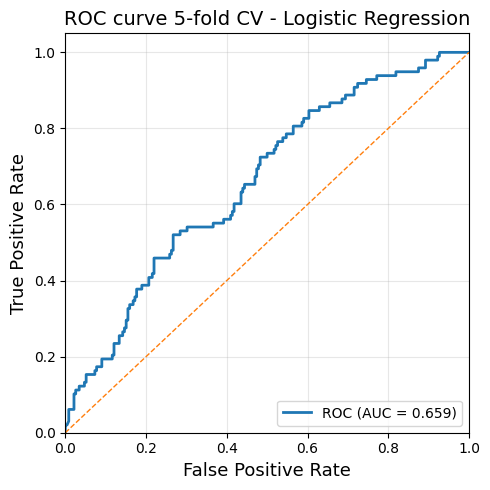

In [34]:
# load the saved predictions and evaluate overall AUC
df_pred = pd.read_excel(os.path.join(out_dir, 'predictions.xlsx'))
y_true = df_pred['Prognosis_label'].values
y_prob = df_pred['pred_prob'].values
overall_auc = roc_auc_score(y_true, y_prob)
print(f"\nOverall AUC across all folds: {overall_auc:.4f}")
plot_roc_curve(y_true,y_prob, figsize = (5,5),title = "ROC curve 5-fold CV - Logistic Regression", save_true = True, save_path = os.path.join(out_dir, 'ROC_curve_5foldCV_LR.pdf'))

### SVM

In [35]:
labels_path = '/host/e/D/Data/Habitats/Jishuitan/Patient_lists/image_label_info_set12_5fold_prognosis.xlsx'
radiomics_path = '/host/d/projects/Habitats/radiomics/whole_image/radiomics_measurements_svm_selected.xlsx'

labels_df = pd.read_excel(labels_path)
radiomics_df = pd.read_excel(radiomics_path)

non_feature_cols = ["Patient_set","Patient_index", "Image_filepath", "Mask_filepath"]
feature_cols = [c for c in radiomics_df.columns if c not in non_feature_cols]
X_all = radiomics_df[feature_cols].values

label_col = 'Prognosis_label'
y_all = labels_df[label_col].values
fold_all = labels_df['fold'].values
print(f'Feature matrix shape: {X_all.shape}', f'Label vector shape: {y_all.shape}', f'Fold vector shape: {fold_all.shape}')

Feature matrix shape: (330, 20) Label vector shape: (330,) Fold vector shape: (330,)


In [ ]:
out_dir = "/host/d/projects/Habitats/models/whole_image/SVM"
os.makedirs(out_dir, exist_ok=True)

random_state = 0

svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
        kernel="linear",
        probability=True,
        class_weight="balanced",
        random_state=random_state
    ))
])

param_grid_svm = {
    "clf__C": [ 0.01,0.1,1, 10, 100],
}

inner_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=random_state
)

grid = GridSearchCV(
    estimator=svm_pipe,
    param_grid=param_grid_svm,
    scoring="roc_auc",
    cv=inner_cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

grid.fit(X_all, y_all)

best_params = grid.best_params_
best_auc_cv = grid.best_score_

print("Best SVM params:", best_params)
print(f"Best mean CV AUC during grid search: {best_auc_cv:.4f}")

with open(os.path.join(out_dir, "best_params.json"), "w") as f:
    json.dump(
        {
            "best_params": best_params,
            "best_gridsearch_auc": float(best_auc_cv)
        },
        f,
        indent=4
    )

grid_results_df = pd.DataFrame(grid.cv_results_)
grid_results_df.to_excel(os.path.join(out_dir, "grid_search_results.xlsx"), index=False)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best SVM params: {'clf__C': 10}
Best mean CV AUC during grid search: 0.7512


In [37]:
out_dir = "/host/d/projects/Habitats/models/whole_image/SVM"
random_state = 0

with open(os.path.join(out_dir, "best_params.json"), "r") as f:
    best_info = json.load(f)

best_params = best_info["best_params"]
print("Loaded best Linear SVM params:", best_params)

fold_aucs = []

df_preds = labels_df[["Patient_set", "Patient_index", "fold", label_col]].copy()
df_preds["pred_prob"] = np.nan

fold_rows = []

for k in range(5):
    print(f"\n========== Fold {k} ==========")

    train_idx = np.where(fold_all != k)[0]
    val_idx = np.where(fold_all == k)[0]

    X_train, y_train = X_all[train_idx], y_all[train_idx]
    X_val, y_val = X_all[val_idx], y_all[val_idx]

    svm_fixed = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(
            kernel="linear",
            C=best_params["clf__C"],
            class_weight="balanced",
            probability=True,
            random_state=random_state
        ))
    ])

    svm_fixed.fit(X_train, y_train)

    prob = svm_fixed.predict_proba(X_val)[:, 1]

    fold_auc = roc_auc_score(y_val, prob)
    fold_aucs.append(fold_auc)

    print(f"Train size: {len(train_idx)}, Val size: {len(val_idx)}")
    print(f"Fold {k} AUC: {fold_auc:.4f}")
    print(f"Probability range: {prob.min():.4f} - {prob.max():.4f}")

    df_preds.loc[val_idx, "pred_prob"] = prob

    fold_rows.append({
        "fold": k,
        "train_size": len(train_idx),
        "val_size": len(val_idx),
        "auc": fold_auc,
        "prob_min": prob.min(),
        "prob_max": prob.max()
    })

pred_path = os.path.join(out_dir, "predictions.xlsx")
df_preds.to_excel(pred_path, index=False)

fold_metrics_df = pd.DataFrame(fold_rows)
fold_metrics_df.to_excel(os.path.join(out_dir, "fold_metrics.xlsx"), index=False)


print("Saved predictions:", pred_path)

# ---- 6. Overall out-of-fold AUC
y_true = df_preds[label_col].values
y_prob = df_preds["pred_prob"].values

overall_auc = roc_auc_score(y_true, y_prob)

# Choose ROC threshold that maximizes (Sensitivity + Specificity)
# Equivalent to maximizing Youden index: TPR - FPR
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
valid_mask = np.isfinite(thresholds)
if valid_mask.any():
    valid_idx = np.where(valid_mask)[0]
    best_local = int(np.argmax(tpr[valid_mask] - fpr[valid_mask]))
    best_idx = int(valid_idx[best_local])
else:
    best_idx = int(np.argmax(tpr - fpr))

best_threshold = float(thresholds[best_idx])
y_pred = (y_prob >= best_threshold).astype(int)

tp = int(np.sum((y_true == 1) & (y_pred == 1)))
fp = int(np.sum((y_true == 0) & (y_pred == 1)))
tn = int(np.sum((y_true == 0) & (y_pred == 0)))
fn = int(np.sum((y_true == 1) & (y_pred == 0)))

accuracy = float((tp + tn) / len(y_true)) if len(y_true) > 0 else float("nan")
sensitivity = float(tp / (tp + fn)) if (tp + fn) > 0 else float("nan")
specificity = float(tn / (tn + fp)) if (tn + fp) > 0 else float("nan")
precision = float(tp / (tp + fp)) if (tp + fp) > 0 else float("nan")
f1 = float((2 * precision * sensitivity) / (precision + sensitivity)) if (precision + sensitivity) > 0 else float("nan")

print("\n========== Linear SVM Summary ==========")
print("Best params:", best_params)
print(f"Fold AUCs: {[round(x, 4) for x in fold_aucs]}")
print(f"Mean fold AUC: {np.mean(fold_aucs):.4f}")
print(f"Std fold AUC: {np.std(fold_aucs):.4f}")
print(f"Overall out-of-fold AUC: {overall_auc:.4f}")
print(f"Best threshold (max SE+SP): {best_threshold:.6f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1: {f1:.4f}")

summary = {
    "model": "Linear SVM",
    "best_params": best_params,
    "best_gridsearch_auc": float(best_info["best_gridsearch_auc"]),
    "fold_aucs": [float(x) for x in fold_aucs],
    "mean_fold_auc": float(np.mean(fold_aucs)),
    "std_fold_auc": float(np.std(fold_aucs)),
    "overall_oof_auc": float(overall_auc),
    "best_threshold_max_se_plus_sp": best_threshold,
    "accuracy": accuracy,
    "sensitivity": sensitivity,
    "specificity": specificity,
    "precision": precision,
    "prevision": precision,
    "f1": f1,
    "tp": tp,
    "fp": fp,
    "tn": tn,
    "fn": fn
}

with open(os.path.join(out_dir, "summary.json"), "w") as f:
    json.dump(summary, f, indent=4)


Loaded best Linear SVM params: {'clf__C': 10}

========== Fold 0 ==========
Train size: 264, Val size: 66
Fold 0 AUC: 0.7290
Probability range: 0.0187 - 1.0000

========== Fold 1 ==========
Train size: 264, Val size: 66
Fold 1 AUC: 0.8830
Probability range: 0.0005 - 0.6500

========== Fold 2 ==========
Train size: 264, Val size: 66
Fold 2 AUC: 0.7228
Probability range: 0.0001 - 0.6459

========== Fold 3 ==========
Train size: 264, Val size: 66
Fold 3 AUC: 0.7304
Probability range: 0.0000 - 0.5257

========== Fold 4 ==========
Train size: 264, Val size: 66
Fold 4 AUC: 0.7304
Probability range: 0.0001 - 0.7047
Saved predictions: /host/d/projects/Habitats/models/whole_image/SVM/predictions.xlsx

========== Linear SVM Summary ==========
Best params: {'clf__C': 10}
Fold AUCs: [0.729, 0.883, 0.7228, 0.7304, 0.7304]
Mean fold AUC: 0.7591
Std fold AUC: 0.0620
Overall out-of-fold AUC: 0.7477
Best threshold (max SE+SP): 0.303927
Accuracy: 0.6909
Sensitivity: 0.7551
Specificity: 0.6638
Precision:


Overall AUC across all folds: 0.7477


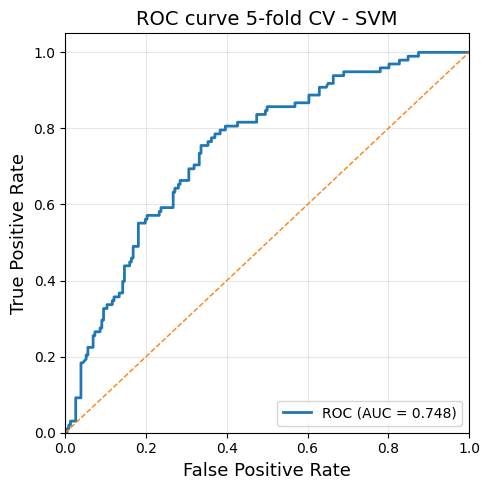

In [38]:
# load the saved predictions and evaluate overall AUC
df_pred = pd.read_excel(os.path.join(out_dir, 'predictions.xlsx'))
y_true = df_pred['Prognosis_label'].values
y_prob = df_pred['pred_prob'].values
overall_auc = roc_auc_score(y_true, y_prob)
print(f"\nOverall AUC across all folds: {overall_auc:.4f}")
plot_roc_curve(y_true,y_prob, figsize = (5,5),title = "ROC curve 5-fold CV - SVM", save_true = True, save_path = os.path.join(out_dir, 'ROC_curve_5foldCV_SVM.pdf'))

### XGBoost

In [39]:
labels_path = '/host/e/D/Data/Habitats/Jishuitan/Patient_lists/image_label_info_set12_5fold_prognosis.xlsx'
radiomics_path = '/host/d/projects/Habitats/radiomics/whole_image/radiomics_measurements_XGBoost_selected.xlsx'

labels_df = pd.read_excel(labels_path)
radiomics_df = pd.read_excel(radiomics_path)

non_feature_cols = ["Patient_set","Patient_index", "Image_filepath", "Mask_filepath"]
feature_cols = [c for c in radiomics_df.columns if c not in non_feature_cols]
X_all = radiomics_df[feature_cols].values

label_col = 'Prognosis_label'
y_all = labels_df[label_col].values
fold_all = labels_df['fold'].values
print(f'Feature matrix shape: {X_all.shape}', f'Label vector shape: {y_all.shape}', f'Fold vector shape: {fold_all.shape}')

Feature matrix shape: (330, 20) Label vector shape: (330,) Fold vector shape: (330,)


In [40]:
out_dir = "/host/d/projects/Habitats/models/whole_image/XGBoost"
os.makedirs(out_dir, exist_ok=True)

random_state = 0

scale_pos_weight = np.sum(y_all == 0) / np.sum(y_all == 1)
print("scale_pos_weight:", scale_pos_weight)

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=random_state,
    n_jobs=1,
    scale_pos_weight=scale_pos_weight,
)

param_grid_xgb = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 4, 5]
}

inner_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=random_state
)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    scoring="roc_auc",
    cv=inner_cv,
    n_jobs=1,
    refit=True,
    verbose=1
)

grid.fit(X_all, y_all)

best_params = grid.best_params_
best_auc_cv = grid.best_score_

print("Best XGBoost params:", best_params)
print(f"Best mean CV AUC during grid search: {best_auc_cv:.4f}")

with open(os.path.join(out_dir, "best_params.json"), "w") as f:
    json.dump(
        {
            "best_params": best_params,
            "best_gridsearch_auc": float(best_auc_cv),
            "scale_pos_weight": float(scale_pos_weight),
        },
        f,
        indent=4
    )

grid_results_df = pd.DataFrame(grid.cv_results_)
grid_results_df.to_excel(os.path.join(out_dir, "grid_search_results.xlsx"), index=False)

scale_pos_weight: 2.36734693877551
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best XGBoost params: {'max_depth': 5, 'n_estimators': 50}
Best mean CV AUC during grid search: 0.6926


In [42]:
out_dir = "/host/d/projects/Habitats/models/whole_image/XGBoost"
random_state = 0

with open(os.path.join(out_dir, "best_params.json"), "r") as f:
    best_info = json.load(f)

best_params = best_info["best_params"]
scale_pos_weight = best_info["scale_pos_weight"]

print("Loaded best XGBoost params:", best_params)
print("Loaded scale_pos_weight:", scale_pos_weight)

fold_aucs = []

df_preds = labels_df[["Patient_set", "Patient_index", "fold", label_col]].copy()
df_preds["pred_prob"] = np.nan

fold_rows = []

for k in range(5):
    print(f"\n========== Fold {k} ==========")

    train_idx = np.where(fold_all != k)[0]
    val_idx = np.where(fold_all == k)[0]

    X_train, y_train = X_all[train_idx], y_all[train_idx]
    X_val, y_val = X_all[val_idx], y_all[val_idx]

    xgb_fixed = XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        random_state=random_state,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,

        n_estimators=best_params["n_estimators"],
        max_depth=best_params["max_depth"],
    )

    xgb_fixed.fit(X_train, y_train)

    prob = xgb_fixed.predict_proba(X_val)[:, 1]

    fold_auc = roc_auc_score(y_val, prob)
    fold_aucs.append(fold_auc)

    print(f"Train size: {len(train_idx)}, Val size: {len(val_idx)}")
    print(f"Fold {k} AUC: {fold_auc:.4f}")
    print(f"Probability range: {prob.min():.4f} - {prob.max():.4f}")

    df_preds.loc[val_idx, "pred_prob"] = prob

    fold_rows.append({
        "fold": k,
        "train_size": len(train_idx),
        "val_size": len(val_idx),
        "auc": fold_auc,
        "prob_min": prob.min(),
        "prob_max": prob.max()
    })

pred_path = os.path.join(out_dir, "predictions.xlsx")
df_preds.to_excel(pred_path, index=False)

fold_metrics_df = pd.DataFrame(fold_rows)
fold_metrics_df.to_excel(os.path.join(out_dir, "fold_metrics.xlsx"), index=False)

y_true = df_preds[label_col].values
y_prob = df_preds["pred_prob"].values

overall_auc = roc_auc_score(y_true, y_prob)

# Choose ROC threshold that maximizes (Sensitivity + Specificity)
# Equivalent to maximizing Youden index: TPR - FPR
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
valid_mask = np.isfinite(thresholds)
if valid_mask.any():
    valid_idx = np.where(valid_mask)[0]
    best_local = int(np.argmax(tpr[valid_mask] - fpr[valid_mask]))
    best_idx = int(valid_idx[best_local])
else:
    best_idx = int(np.argmax(tpr - fpr))

best_threshold = float(thresholds[best_idx])
y_pred = (y_prob >= best_threshold).astype(int)

tp = int(np.sum((y_true == 1) & (y_pred == 1)))
fp = int(np.sum((y_true == 0) & (y_pred == 1)))
tn = int(np.sum((y_true == 0) & (y_pred == 0)))
fn = int(np.sum((y_true == 1) & (y_pred == 0)))

accuracy = float((tp + tn) / len(y_true)) if len(y_true) > 0 else float("nan")
sensitivity = float(tp / (tp + fn)) if (tp + fn) > 0 else float("nan")
specificity = float(tn / (tn + fp)) if (tn + fp) > 0 else float("nan")
precision = float(tp / (tp + fp)) if (tp + fp) > 0 else float("nan")
f1 = float((2 * precision * sensitivity) / (precision + sensitivity)) if (precision + sensitivity) > 0 else float("nan")

print("\n========== XGBoost Summary ==========")
print("Best params:", best_params)
print(f"Fold AUCs: {[round(x, 4) for x in fold_aucs]}")
print(f"Mean fold AUC: {np.mean(fold_aucs):.4f}")
print(f"Std fold AUC: {np.std(fold_aucs):.4f}")
print(f"Overall out-of-fold AUC: {overall_auc:.4f}")
print(f"Best threshold (max SE+SP): {best_threshold:.6f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1: {f1:.4f}")

summary = {
    "model": "XGBoost",
    "best_params": best_params,
    "best_gridsearch_auc": float(best_info["best_gridsearch_auc"]),
    "scale_pos_weight": float(scale_pos_weight),
    "fold_aucs": [float(x) for x in fold_aucs],
    "mean_fold_auc": float(np.mean(fold_aucs)),
    "std_fold_auc": float(np.std(fold_aucs)),
    "overall_oof_auc": float(overall_auc),
    "best_threshold_max_se_plus_sp": best_threshold,
    "accuracy": accuracy,
    "sensitivity": sensitivity,
    "specificity": specificity,
    "precision": precision,
    "prevision": precision,
    "f1": f1,
    "tp": tp,
    "fp": fp,
    "tn": tn,
    "fn": fn
}

with open(os.path.join(out_dir, "summary.json"), "w") as f:
    json.dump(summary, f, indent=4)
print("Saved predictions:", pred_path)

Loaded best XGBoost params: {'max_depth': 5, 'n_estimators': 50}
Loaded scale_pos_weight: 2.36734693877551

========== Fold 0 ==========
Train size: 264, Val size: 66
Fold 0 AUC: 0.7044
Probability range: 0.0012 - 0.9107

========== Fold 1 ==========
Train size: 264, Val size: 66
Fold 1 AUC: 0.7380
Probability range: 0.0034 - 0.9761

========== Fold 2 ==========
Train size: 264, Val size: 66
Fold 2 AUC: 0.7054
Probability range: 0.0028 - 0.9904

========== Fold 3 ==========
Train size: 264, Val size: 66
Fold 3 AUC: 0.5696
Probability range: 0.0022 - 0.9834

========== Fold 4 ==========
Train size: 264, Val size: 66
Fold 4 AUC: 0.7457
Probability range: 0.0016 - 0.9766

========== XGBoost Summary ==========
Best params: {'max_depth': 5, 'n_estimators': 50}
Fold AUCs: [0.7044, 0.738, 0.7054, 0.5696, 0.7457]
Mean fold AUC: 0.6926
Std fold AUC: 0.0637
Overall out-of-fold AUC: 0.6905
Best threshold (max SE+SP): 0.222971
Accuracy: 0.6485
Sensitivity: 0.6327
Specificity: 0.6552
Precision: 0.4


Overall AUC across all folds: 0.7274


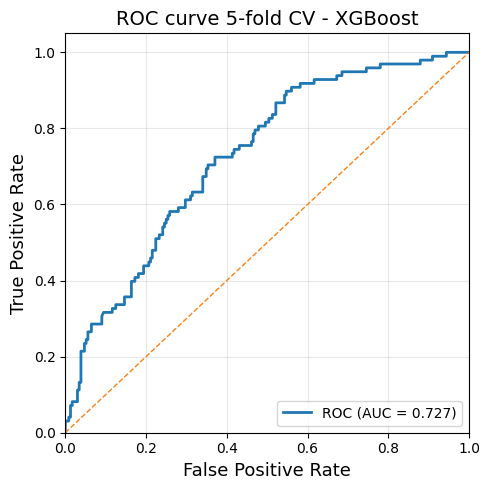

In [18]:
out_dir = "/host/d/projects/Habitats/models/whole_image/XGBoost"

df_pred = pd.read_excel(os.path.join(out_dir, "predictions.xlsx"))

y_true = df_pred[label_col].values
y_prob = df_pred["pred_prob"].values

overall_auc = roc_auc_score(y_true, y_prob)
print(f"\nOverall AUC across all folds: {overall_auc:.4f}")

plot_roc_curve(
    y_true,
    y_prob,
    figsize=(5, 5),
    title="ROC curve 5-fold CV - XGBoost",
    save_true=True,
    save_path=os.path.join(out_dir, "ROC_curve_5foldCV_XGBoost.pdf")
)

### Random forest

In [43]:
labels_path = '/host/e/D/Data/Habitats/Jishuitan/Patient_lists/image_label_info_set12_5fold_prognosis.xlsx'
radiomics_path = '/host/d/projects/Habitats/radiomics/whole_image/radiomics_measurements_RF_selected.xlsx'

labels_df = pd.read_excel(labels_path)
radiomics_df = pd.read_excel(radiomics_path)

non_feature_cols = ["Patient_set", "Patient_index", "Image_filepath", "Mask_filepath"]
feature_cols = [c for c in radiomics_df.columns if c not in non_feature_cols]

X_all = radiomics_df[feature_cols].values

label_col = 'Prognosis_label'
y_all = labels_df[label_col].values
fold_all = labels_df['fold'].values

print(
    f'Feature matrix shape: {X_all.shape}',
    f'Label vector shape: {y_all.shape}',
    f'Fold vector shape: {fold_all.shape}'
)

print("Label counts:")
print(pd.Series(y_all).value_counts())

Feature matrix shape: (330, 20) Label vector shape: (330,) Fold vector shape: (330,)
Label counts:
0    232
1     98
dtype: int64


In [44]:

out_dir = "/host/d/projects/Habitats/models/whole_image/RandomForest"
os.makedirs(out_dir, exist_ok=True)

random_state = 0

rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=random_state,
    n_jobs=1,
    max_features="sqrt",
)

param_grid_rf = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 3, 5],

}

inner_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=random_state
)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring="roc_auc",
    cv=inner_cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

grid.fit(X_all, y_all)

best_params = grid.best_params_
best_auc_cv = grid.best_score_

print("Best Random Forest params:", best_params)
print(f"Best mean CV AUC during grid search: {best_auc_cv:.4f}")

with open(os.path.join(out_dir, "best_params.json"), "w") as f:
    json.dump(
        {
            "best_params": best_params,
            "best_gridsearch_auc": float(best_auc_cv),
            "fixed_params": {
                "class_weight": "balanced"
            }
        },
        f,
        indent=4
    )

grid_results_df = pd.DataFrame(grid.cv_results_)
grid_results_df.to_excel(os.path.join(out_dir, "grid_search_results.xlsx"), index=False)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


Best Random Forest params: {'max_depth': 5, 'n_estimators': 500}
Best mean CV AUC during grid search: 0.7086


In [45]:

out_dir = "/host/d/projects/Habitats/models/whole_image/RandomForest"
random_state = 0

with open(os.path.join(out_dir, "best_params.json"), "r") as f:
    best_info = json.load(f)

best_params = best_info["best_params"]

print("Loaded best Random Forest params:", best_params)

fold_aucs = []

df_preds = labels_df[["Patient_set", "Patient_index", "fold", label_col]].copy()
df_preds["pred_prob"] = np.nan

fold_rows = []

for k in range(5):
    print(f"\n========== Fold {k} ==========")

    train_idx = np.where(fold_all != k)[0]
    val_idx = np.where(fold_all == k)[0]

    X_train, y_train = X_all[train_idx], y_all[train_idx]
    X_val, y_val = X_all[val_idx], y_all[val_idx]

    rf_fixed = RandomForestClassifier(
        n_estimators=best_params["n_estimators"],
        max_depth=best_params["max_depth"],
        max_features="sqrt",
        class_weight="balanced",
        random_state=random_state,
        n_jobs=-1
    )

    rf_fixed.fit(X_train, y_train)

    prob = rf_fixed.predict_proba(X_val)[:, 1]

    fold_auc = roc_auc_score(y_val, prob)
    fold_aucs.append(fold_auc)

    print(f"Train size: {len(train_idx)}, Val size: {len(val_idx)}")
    print(f"Fold {k} AUC: {fold_auc:.4f}")
    print(f"Probability range: {prob.min():.4f} - {prob.max():.4f}")

    df_preds.loc[val_idx, "pred_prob"] = prob

    fold_rows.append({
        "fold": k,
        "train_size": len(train_idx),
        "val_size": len(val_idx),
        "auc": fold_auc,
        "prob_min": prob.min(),
        "prob_max": prob.max()
    })

pred_path = os.path.join(out_dir, "predictions.xlsx")
df_preds.to_excel(pred_path, index=False)

fold_metrics_df = pd.DataFrame(fold_rows)
fold_metrics_df.to_excel(os.path.join(out_dir, "fold_metrics.xlsx"), index=False)

y_true = df_preds[label_col].values
y_prob = df_preds["pred_prob"].values

overall_auc = roc_auc_score(y_true, y_prob)

# Choose ROC threshold that maximizes (Sensitivity + Specificity)
# Equivalent to maximizing Youden index: TPR - FPR
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
valid_mask = np.isfinite(thresholds)
if valid_mask.any():
    valid_idx = np.where(valid_mask)[0]
    best_local = int(np.argmax(tpr[valid_mask] - fpr[valid_mask]))
    best_idx = int(valid_idx[best_local])
else:
    best_idx = int(np.argmax(tpr - fpr))

best_threshold = float(thresholds[best_idx])
y_pred = (y_prob >= best_threshold).astype(int)

tp = int(np.sum((y_true == 1) & (y_pred == 1)))
fp = int(np.sum((y_true == 0) & (y_pred == 1)))
tn = int(np.sum((y_true == 0) & (y_pred == 0)))
fn = int(np.sum((y_true == 1) & (y_pred == 0)))

accuracy = float((tp + tn) / len(y_true)) if len(y_true) > 0 else float("nan")
sensitivity = float(tp / (tp + fn)) if (tp + fn) > 0 else float("nan")
specificity = float(tn / (tn + fp)) if (tn + fp) > 0 else float("nan")
precision = float(tp / (tp + fp)) if (tp + fp) > 0 else float("nan")
f1 = float((2 * precision * sensitivity) / (precision + sensitivity)) if (precision + sensitivity) > 0 else float("nan")

print("\n========== Random Forest Summary ==========")
print("Best params:", best_params)
print(f"Fold AUCs: {[round(x, 4) for x in fold_aucs]}")
print(f"Mean fold AUC: {np.mean(fold_aucs):.4f}")
print(f"Std fold AUC: {np.std(fold_aucs):.4f}")
print(f"Overall out-of-fold AUC: {overall_auc:.4f}")
print(f"Best threshold (max SE+SP): {best_threshold:.6f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1: {f1:.4f}")

summary = {
    "model": "Random Forest",
    "best_params": best_params,
    "best_gridsearch_auc": float(best_info["best_gridsearch_auc"]),
    "fold_aucs": [float(x) for x in fold_aucs],
    "mean_fold_auc": float(np.mean(fold_aucs)),
    "std_fold_auc": float(np.std(fold_aucs)),
    "overall_oof_auc": float(overall_auc),
    "best_threshold_max_se_plus_sp": best_threshold,
    "accuracy": accuracy,
    "sensitivity": sensitivity,
    "specificity": specificity,
    "precision": precision,
    "prevision": precision,
    "f1": f1,
    "tp": tp,
    "fp": fp,
    "tn": tn,
    "fn": fn
}

with open(os.path.join(out_dir, "summary.json"), "w") as f:
    json.dump(summary, f, indent=4)
print("Saved predictions:", pred_path)

Loaded best Random Forest params: {'max_depth': 5, 'n_estimators': 500}

========== Fold 0 ==========
Train size: 264, Val size: 66
Fold 0 AUC: 0.7335
Probability range: 0.0285 - 0.6538

========== Fold 1 ==========
Train size: 264, Val size: 66
Fold 1 AUC: 0.6713
Probability range: 0.0926 - 0.7850

========== Fold 2 ==========
Train size: 264, Val size: 66
Fold 2 AUC: 0.7826
Probability range: 0.0703 - 0.7033

========== Fold 3 ==========
Train size: 264, Val size: 66
Fold 3 AUC: 0.5848
Probability range: 0.0537 - 0.6608

========== Fold 4 ==========
Train size: 264, Val size: 66
Fold 4 AUC: 0.7707
Probability range: 0.0861 - 0.7632

========== Random Forest Summary ==========
Best params: {'max_depth': 5, 'n_estimators': 500}
Fold AUCs: [0.7335, 0.6713, 0.7826, 0.5848, 0.7707]
Mean fold AUC: 0.7086
Std fold AUC: 0.0730
Overall out-of-fold AUC: 0.7006
Best threshold (max SE+SP): 0.349709
Accuracy: 0.6030
Sensitivity: 0.8061
Specificity: 0.5172
Precision: 0.4136
F1: 0.5467
Saved predic


Overall AUC across all folds: 0.7082


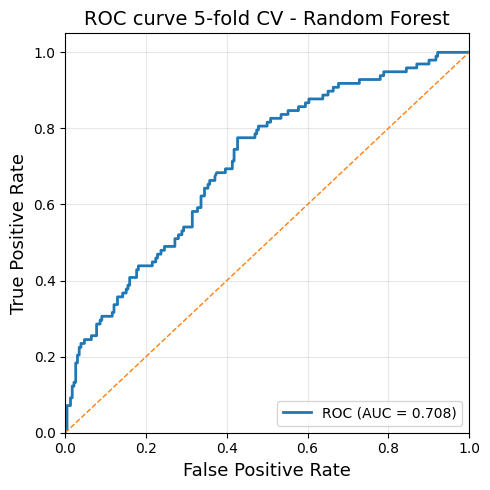

In [22]:
# load the saved predictions and evaluate overall AUC
df_pred = pd.read_excel(os.path.join(out_dir, 'predictions.xlsx'))
y_true = df_pred['Prognosis_label'].values
y_prob = df_pred['pred_prob'].values
overall_auc = roc_auc_score(y_true, y_prob)
print(f"\nOverall AUC across all folds: {overall_auc:.4f}")

plot_roc_curve(y_true, y_prob, figsize = (5,5),title = "ROC curve 5-fold CV - Random Forest", save_true = True, save_path = os.path.join(out_dir, 'ROC_curve_5foldCV_RandomForest.pdf'))

## KNN

In [46]:
labels_path = '/host/e/D/Data/Habitats/Jishuitan/Patient_lists/image_label_info_set12_5fold_prognosis.xlsx'
radiomics_path = '/host/d/projects/Habitats/radiomics/whole_image/radiomics_measurements_KNN_SFS_selected.xlsx'

labels_df = pd.read_excel(labels_path)
radiomics_df = pd.read_excel(radiomics_path)

non_feature_cols = ["Patient_set", "Patient_index", "Image_filepath", "Mask_filepath"]
feature_cols = [c for c in radiomics_df.columns if c not in non_feature_cols]

X_all = radiomics_df[feature_cols].values

label_col = 'Prognosis_label'
y_all = labels_df[label_col].values
fold_all = labels_df['fold'].values

print(
    f'Feature matrix shape: {X_all.shape}',
    f'Label vector shape: {y_all.shape}',
    f'Fold vector shape: {fold_all.shape}'
)

print("Label counts:")
print(pd.Series(y_all).value_counts())

Feature matrix shape: (330, 20) Label vector shape: (330,) Fold vector shape: (330,)
Label counts:
0    232
1     98
dtype: int64


In [47]:

out_dir = "/host/d/projects/Habitats/models/whole_image/KNN"
os.makedirs(out_dir, exist_ok=True)

random_state = 0

knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier())
])

param_grid_knn = {
    "clf__n_neighbors": [3,  7, 9, 11],
    "clf__weights": ["uniform", "distance"],
}

inner_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=random_state
)

grid = GridSearchCV(
    estimator=knn_pipe,
    param_grid=param_grid_knn,
    scoring="roc_auc",
    cv=inner_cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

grid.fit(X_all, y_all)

best_params = grid.best_params_
best_auc_cv = grid.best_score_

print("Best KNN params:", best_params)
print(f"Best mean CV AUC during grid search: {best_auc_cv:.4f}")

with open(os.path.join(out_dir, "best_params.json"), "w") as f:
    json.dump(
        {
            "best_params": best_params,
            "best_gridsearch_auc": float(best_auc_cv)
        },
        f,
        indent=4
    )

grid_results_df = pd.DataFrame(grid.cv_results_)
grid_results_df.to_excel(os.path.join(out_dir, "grid_search_results.xlsx"), index=False)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best KNN params: {'clf__n_neighbors': 3, 'clf__weights': 'distance'}
Best mean CV AUC during grid search: 0.6916


In [48]:

out_dir = "/host/d/projects/Habitats/models/whole_image/KNN"
random_state = 0

with open(os.path.join(out_dir, "best_params.json"), "r") as f:
    best_info = json.load(f)

best_params = best_info["best_params"]

print("Loaded best KNN params:", best_params)

fold_aucs = []

df_preds = labels_df[["Patient_set", "Patient_index", "fold", label_col]].copy()
df_preds["pred_prob"] = np.nan

fold_rows = []

for k in range(5):
    print(f"\n========== Fold {k} ==========")

    train_idx = np.where(fold_all != k)[0]
    val_idx = np.where(fold_all == k)[0]

    X_train, y_train = X_all[train_idx], y_all[train_idx]
    X_val, y_val = X_all[val_idx], y_all[val_idx]

    knn_fixed = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(
            n_neighbors=best_params["clf__n_neighbors"],
            weights=best_params["clf__weights"],
           
        ))
    ])

    knn_fixed.fit(X_train, y_train)

    prob = knn_fixed.predict_proba(X_val)[:, 1]

    fold_auc = roc_auc_score(y_val, prob)
    fold_aucs.append(fold_auc)

    print(f"Train size: {len(train_idx)}, Val size: {len(val_idx)}")
    print(f"Fold {k} AUC: {fold_auc:.4f}")
    print(f"Probability range: {prob.min():.4f} - {prob.max():.4f}")

    df_preds.loc[val_idx, "pred_prob"] = prob

    fold_rows.append({
        "fold": k,
        "train_size": len(train_idx),
        "val_size": len(val_idx),
        "auc": fold_auc,
        "prob_min": prob.min(),
        "prob_max": prob.max()
    })

pred_path = os.path.join(out_dir, "predictions.xlsx")
df_preds.to_excel(pred_path, index=False)

fold_metrics_df = pd.DataFrame(fold_rows)
fold_metrics_df.to_excel(os.path.join(out_dir, "fold_metrics.xlsx"), index=False)

y_true = df_preds[label_col].values
y_prob = df_preds["pred_prob"].values

overall_auc = roc_auc_score(y_true, y_prob)

# Choose ROC threshold that maximizes (Sensitivity + Specificity)
# Equivalent to maximizing Youden index: TPR - FPR
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
valid_mask = np.isfinite(thresholds)
if valid_mask.any():
    valid_idx = np.where(valid_mask)[0]
    best_local = int(np.argmax(tpr[valid_mask] - fpr[valid_mask]))
    best_idx = int(valid_idx[best_local])
else:
    best_idx = int(np.argmax(tpr - fpr))

best_threshold = float(thresholds[best_idx])
y_pred = (y_prob >= best_threshold).astype(int)

tp = int(np.sum((y_true == 1) & (y_pred == 1)))
fp = int(np.sum((y_true == 0) & (y_pred == 1)))
tn = int(np.sum((y_true == 0) & (y_pred == 0)))
fn = int(np.sum((y_true == 1) & (y_pred == 0)))

accuracy = float((tp + tn) / len(y_true)) if len(y_true) > 0 else float("nan")
sensitivity = float(tp / (tp + fn)) if (tp + fn) > 0 else float("nan")
specificity = float(tn / (tn + fp)) if (tn + fp) > 0 else float("nan")
precision = float(tp / (tp + fp)) if (tp + fp) > 0 else float("nan")
f1 = float((2 * precision * sensitivity) / (precision + sensitivity)) if (precision + sensitivity) > 0 else float("nan")

print("\n========== KNN Summary ==========")
print("Best params:", best_params)
print(f"Fold AUCs: {[round(x, 4) for x in fold_aucs]}")
print(f"Mean fold AUC: {np.mean(fold_aucs):.4f}")
print(f"Std fold AUC: {np.std(fold_aucs):.4f}")
print(f"Overall out-of-fold AUC: {overall_auc:.4f}")
print(f"Best threshold (max SE+SP): {best_threshold:.6f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1: {f1:.4f}")

summary = {
    "model": "KNN",
    "best_params": best_params,
    "best_gridsearch_auc": float(best_info["best_gridsearch_auc"]),
    "fold_aucs": [float(x) for x in fold_aucs],
    "mean_fold_auc": float(np.mean(fold_aucs)),
    "std_fold_auc": float(np.std(fold_aucs)),
    "overall_oof_auc": float(overall_auc),
    "best_threshold_max_se_plus_sp": best_threshold,
    "accuracy": accuracy,
    "sensitivity": sensitivity,
    "specificity": specificity,
    "precision": precision,
    "prevision": precision,
    "f1": f1,
    "tp": tp,
    "fp": fp,
    "tn": tn,
    "fn": fn
}

with open(os.path.join(out_dir, "summary.json"), "w") as f:
    json.dump(summary, f, indent=4)
print("Saved predictions:", pred_path)

Loaded best KNN params: {'clf__n_neighbors': 3, 'clf__weights': 'distance'}

========== Fold 0 ==========
Train size: 264, Val size: 66
Fold 0 AUC: 0.7156
Probability range: 0.0000 - 1.0000

========== Fold 1 ==========
Train size: 264, Val size: 66
Fold 1 AUC: 0.6999
Probability range: 0.0000 - 1.0000

========== Fold 2 ==========
Train size: 264, Val size: 66
Fold 2 AUC: 0.7293
Probability range: 0.0000 - 1.0000

========== Fold 3 ==========
Train size: 264, Val size: 66
Fold 3 AUC: 0.5054
Probability range: 0.0000 - 1.0000

========== Fold 4 ==========
Train size: 264, Val size: 66
Fold 4 AUC: 0.8076
Probability range: 0.0000 - 1.0000

========== KNN Summary ==========
Best params: {'clf__n_neighbors': 3, 'clf__weights': 'distance'}
Fold AUCs: [0.7156, 0.6999, 0.7293, 0.5054, 0.8076]
Mean fold AUC: 0.6916
Std fold AUC: 0.1002
Overall out-of-fold AUC: 0.6931
Best threshold (max SE+SP): 0.362961
Accuracy: 0.7182
Sensitivity: 0.5510
Specificity: 0.7888
Precision: 0.5243
F1: 0.5373
Save


Overall AUC across all folds: 0.7221


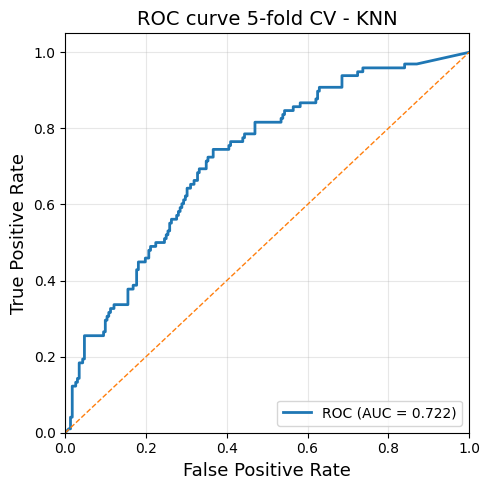

In [ ]:
out_dir = "/host/d/projects/Habitats/models/whole_image/KNN"

df_pred = pd.read_excel(os.path.join(out_dir, "predictions.xlsx"))

y_true = df_pred[label_col].values
y_prob = df_pred["pred_prob"].values

overall_auc = roc_auc_score(y_true, y_prob)
print(f"\nOverall AUC across all folds: {overall_auc:.4f}")

plot_roc_curve(
    y_true,
    y_prob,
    figsize=(5, 5),
    title="ROC curve 5-fold CV - KNN",
    save_true=True,
    save_path=os.path.join(out_dir, "ROC_curve_5foldCV_KNN.pdf")
)

### Power analysis

In [17]:

def norm_cdf(x):
    return 0.5 * (1 + erf(x / sqrt(2)))

def se_auc_hanley_mcneil(auc, n1, n0):
    Q1 = auc / (2 - auc)
    Q2 = 2 * auc * auc / (1 + auc)
    var = (auc*(1-auc) + (n1-1)*(Q1-auc*auc) + (n0-1)*(Q2-auc*auc)) / (n0*n1)
    return math.sqrt(var)

def power_auc(N, n_pos, auc_true, auc0=0.5, alpha=0.05):
    # two-sided alpha
    z_alpha = 1.959963984540054  # = norm.ppf(1-alpha/2) for alpha=0.05
    n1 = n_pos
    n0 = N - n1
    se = se_auc_hanley_mcneil(auc_true, n1, n0)
    delta = (auc_true - auc0) / se
    power = 1 - norm_cdf(z_alpha - delta)  # approx for auc_true > auc0
    return power

def required_N_for_power(pos_rate, auc_true, auc0=0.5, alpha=0.05, target_power=0.8,
                         N_min=30, N_max=5000):
    """
    Find the smallest N such that power >= target_power,
    with n_pos = round(pos_rate * N) and n_neg = N - n_pos.
    """
    for N in range(N_min, N_max + 1):
        n_pos = int(round(pos_rate * N))
        # make sure both classes exist
        n_pos = max(1, min(N-1, n_pos))
        pw = power_auc(N, n_pos, auc_true, auc0=auc0, alpha=alpha)
        if pw >= target_power:
            return N, n_pos, pw
    return None, None, None

# ====== your setting ======
pos_rate = 21 / 81   # ~0.259
alpha = 0.05
target_power = 0.8

for auc_true in [0.75, 0.80]:
    for auc0 in [0.5, 0.6, 0.65, 0.7]:
        N_star, npos_star, pw_star = required_N_for_power(
            pos_rate=pos_rate,
            auc_true=auc_true,
            auc0=auc0,
            alpha=alpha,
            target_power=target_power,
            N_min=30,
            N_max=5000
        )
        print(f"AUC_true={auc_true:.2f}, AUC0={auc0:.2f} -> "
              f"required N={N_star}, (npos≈{npos_star}), power≈{pw_star:.3f}")


AUC_true=0.75, AUC0=0.50 -> required N=47, (npos≈12), power≈0.801
AUC_true=0.75, AUC0=0.60 -> required N=126, (npos≈33), power≈0.801
AUC_true=0.75, AUC0=0.65 -> required N=284, (npos≈74), power≈0.802
AUC_true=0.75, AUC0=0.70 -> required N=1133, (npos≈294), power≈0.800
AUC_true=0.80, AUC0=0.50 -> required N=30, (npos≈8), power≈0.835
AUC_true=0.80, AUC0=0.60 -> required N=63, (npos≈16), power≈0.800
AUC_true=0.80, AUC0=0.65 -> required N=110, (npos≈29), power≈0.808
AUC_true=0.80, AUC0=0.70 -> required N=245, (npos≈64), power≈0.803
